## Ensemble Approach

In [1]:
!pip install numpy
!pip install matplotlib
!pip install scipy
!pip install scikit-learn
!pip install pandas
!pip install seaborn
!pip install tensorflow
!pip install torch
!pip install xgboost
!pip install torchvision
!pip install opencv-python


In [86]:
#Section 1 - Import Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import cv2
import random
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from sklearn.model_selection import train_test_split
from torchvision import models
from sklearn.metrics import accuracy_score

In [3]:
#Section 2 - Device Configuration

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple GPU (MPS)")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using device: cpu
Using Apple GPU (MPS)


In [127]:
from src.data_loader import *
from src.transforms import *
from src.models import *
from src.train import *
from src.evaluate import *
print("Data Loader Imported Successfully")

Data Loader Imported Successfully


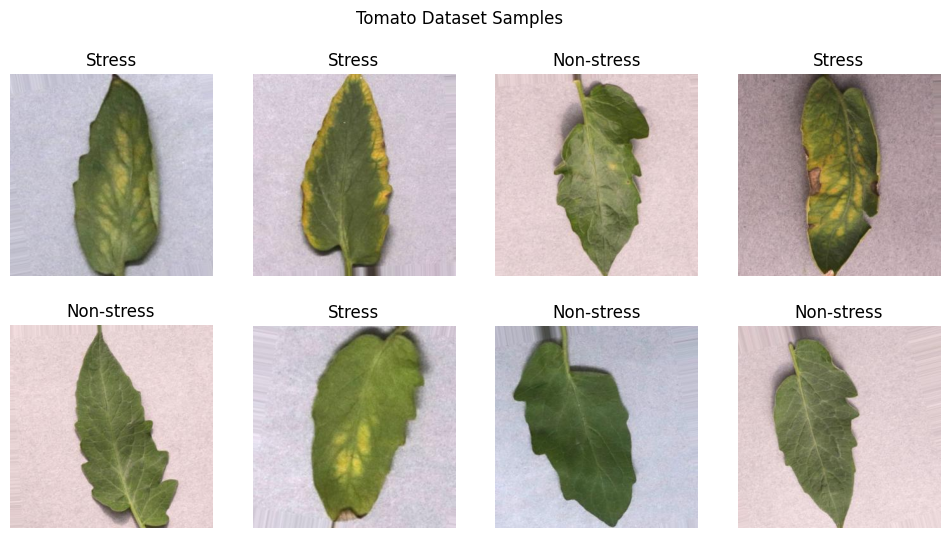

In [116]:
#Section 8 - View sample Images
label_names = {
    0: "Non-stress",
    1: "Stress"
}

random_indices = random.sample(range(len(tomato_images)), 8)

plt.figure(figsize=(12,6))

for i, idx in enumerate(random_indices):

    image = cv2.imread(tomato_images[idx])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    label = tomato_labels[idx]

    plt.subplot(2,4,i+1)
    plt.imshow(image)
    plt.title(label_names[label])   # class name
    plt.axis("off")

plt.suptitle("Tomato Dataset Samples")
plt.show()

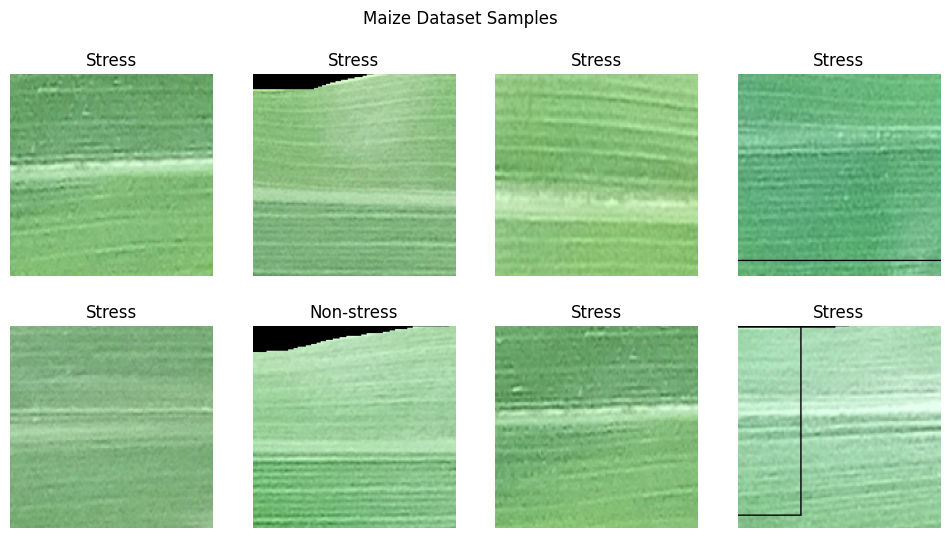

In [117]:
random_indices = random.sample(range(len(maize_images)), 8)

plt.figure(figsize=(12,6))

for i, idx in enumerate(random_indices):

    image = cv2.imread(maize_images[idx])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    label = maize_labels[idx]

    plt.subplot(2,4,i+1)
    plt.imshow(image)
    plt.title(label_names[label])   # class name
    plt.axis("off")

plt.suptitle("Maize Dataset Samples")
plt.show()

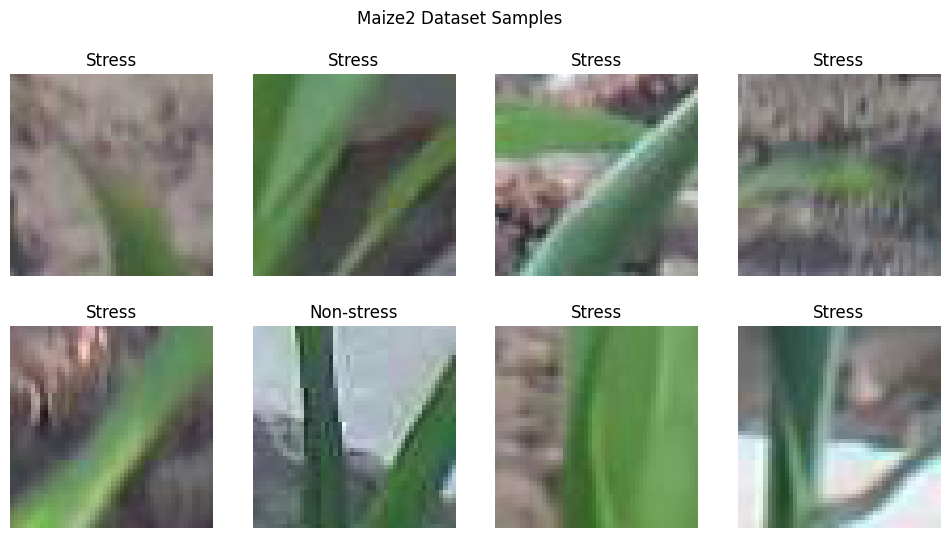

In [14]:
# Random sample indices
random_indices = random.sample(range(len(train_maize2_data)), 8)

plt.figure(figsize=(12,6))

for i, idx in enumerate(random_indices):

    # Directly get image array
    image = train_maize2_data[idx]

    # Get label
    label = train_maize2_labels[idx]

    plt.subplot(2,4,i+1)

    # Display image
    plt.imshow(image.astype("uint8"))

    plt.title(label_names[label])

    plt.axis("off")

plt.suptitle("Maize2 Dataset Samples")

plt.show()

In [17]:
#Section 10 - Create Dataset and Dataloaders

tomato_train_dataset = LeafDataset(
    train_tomato_data, train_tomato_labels, transform)

maize_train_dataset = LeafDataset(
    train_maize_data, train_maize_labels, transform)

maize2_train_dataset = LeafDataset(
    train_maize2_data, train_maize2_labels, transform)


tomato_val_dataset = LeafDataset(
    val_tomato_data, val_tomato_labels, transform)

maize_val_dataset = LeafDataset(
    val_maize_data, val_maize_labels, transform)

maize2_val_dataset = LeafDataset(
    val_maize2_data, val_maize2_labels, transform)


tomato_test_dataset = LeafDataset(
    test_tomato_data, test_tomato_labels, transform)

maize_test_dataset = LeafDataset(
    test_maize_data, test_maize_labels, transform)

maize2_test_dataset = LeafDataset(
    test_maize2_data, test_maize2_labels, transform)

batch_size = 32

tomato_train_loader = DataLoader(
    tomato_train_dataset, batch_size=batch_size, shuffle=True)
tomato_val_loader = DataLoader(
    tomato_val_dataset, batch_size=batch_size, shuffle=False)
tomato_test_loader = DataLoader(
    tomato_test_dataset, batch_size=batch_size, shuffle=False)

maize_train_loader = DataLoader(
    maize_train_dataset, batch_size=batch_size, shuffle=True)
maize_val_loader = DataLoader(
    maize_val_dataset, batch_size=batch_size, shuffle=False)
maize_test_loader = DataLoader(
    maize_test_dataset, batch_size=batch_size, shuffle=False)

maize2_train_loader = DataLoader(
    maize2_train_dataset, batch_size=batch_size, shuffle=True)
maize2_val_loader = DataLoader(
    maize2_val_dataset, batch_size=batch_size, shuffle=False)
maize2_test_loader = DataLoader(
    maize2_test_dataset, batch_size=batch_size, shuffle=False)

In [20]:
#Section 13 - Loss Function and Optimizer

criterion = nn.CrossEntropyLoss()

# Tomato Optimizer
tomato_optimizer = torch.optim.Adam(
    tomato_model.parameters(),
    lr=0.001
)

# Maize Optimizer
maize_optimizer = torch.optim.Adam(
    maize_model.parameters(),
    lr=0.001
)

# Maize2 Optimizer
maize2_optimizer = torch.optim.Adam(
    maize2_model.parameters(),
    lr=0.001
)

In [22]:
#Section 15 - Train baseline model

print("Training Tomato Model")

train_model(
    tomato_model,
    tomato_train_loader,
    tomato_val_loader,
    tomato_optimizer,
    epochs=5
)

print("Training Maize Model")

train_model(
    maize_model,
    maize_train_loader,
    maize_val_loader,
    maize_optimizer,
    epochs=5
)

print("Training Maize2 Model")

train_model(
    maize2_model,
    maize2_train_loader,
    maize2_val_loader,
    maize2_optimizer,
    epochs=5
)


Training Tomato Model
Epoch [1/5]
Train Loss: 0.0303
Validation Accuracy: 99.65%
----------------------------------------
Epoch [2/5]
Train Loss: 0.0198
Validation Accuracy: 99.97%
----------------------------------------
Epoch [3/5]
Train Loss: 0.0114
Validation Accuracy: 99.84%
----------------------------------------
Epoch [4/5]
Train Loss: 0.0088
Validation Accuracy: 99.90%
----------------------------------------
Epoch [5/5]
Train Loss: 0.0122
Validation Accuracy: 99.55%
----------------------------------------
Training Maize Model
Epoch [1/5]
Train Loss: 0.2014
Validation Accuracy: 25.00%
----------------------------------------
Epoch [2/5]
Train Loss: 0.1370
Validation Accuracy: 26.67%
----------------------------------------
Epoch [3/5]
Train Loss: 0.0952
Validation Accuracy: 73.33%
----------------------------------------
Epoch [4/5]
Train Loss: 0.0598
Validation Accuracy: 81.67%
----------------------------------------
Epoch [5/5]
Train Loss: 0.0194
Validation Accuracy: 90.00

([0.14245653757515053,
  0.08965517024199168,
  0.0906950785483544,
  0.06816128196039548,
  0.06197649112980192],
 [86.05427974947808,
  95.78288100208768,
  93.06889352818372,
  91.8580375782881,
  94.07098121085595])

In [25]:
#Section 17 - Test Individual Models

print("Tomato Model Performance")
tomato_acc = evaluate_model(
    tomato_model,
    tomato_test_loader
)

print("Maize Model Performance")
maize_acc = evaluate_model(
    maize_model,
    maize_test_loader
)

print("Maize2 Model Performance")
maize2_acc = evaluate_model(
    maize2_model,
    maize2_test_loader
)

Tomato Model Performance
Test Accuracy: 99.49%
Maize Model Performance
Test Accuracy: 93.33%
Maize2 Model Performance
Test Accuracy: 93.98%


In [30]:
#Section 19 - Test Ensemble Model

sample_image, sample_label = tomato_test_dataset[0]

prediction = ensemble_predict(sample_image)

print("Actual Label:", sample_label)
print("Predicted Label:", prediction)

Actual Label: 1
Predicted Label: 1


In [40]:
#Section 20 - Merge all test datasets for ensemble evaluation

# Combine all test images
merged_test_data = (
    test_tomato_data +
    test_maize_data +
    list(test_maize2_data)
)

# Combine all test labels

merged_test_labels = (
    list(test_tomato_labels) +
    list(test_maize_labels) +
    list(test_maize2_labels)
)

print("Total Test Images:", len(merged_test_data))
print("Total Test Labels:", len(merged_test_labels))

Total Test Images: 9269
Total Test Labels: 9269


In [44]:
merged_test_dataset = LeafDataset(
    merged_test_data,
    merged_test_labels,
    transform
)

In [47]:
ensemble_acc = evaluate_ensemble(
    merged_test_dataset
)

Ensemble Accuracy: 72.05%


# Version 2 - Fine-tunned Ensemble Model 

In [ ]:
#Section2 - Create Improved Datasets

improved_tomato_train_dataset = LeafDataset(
    train_tomato_data, train_tomato_labels, improved_transform
)
improved_tomato_val_dataset = LeafDataset(
    val_tomato_data, val_tomato_labels, improved_transform
)
improved_tomato_test_dataset = LeafDataset(
    test_tomato_data, test_tomato_labels, improved_transform
)

improved_maize_train_dataset = LeafDataset(
    train_maize_data, train_maize_labels, improved_transform
)   
improved_maize_val_dataset = LeafDataset(
    val_maize_data, val_maize_labels, improved_transform
)
improved_maize_test_dataset = LeafDataset(
    test_maize_data, test_maize_labels, improved_transform
)

improved_maize2_train_dataset = LeafDataset(
    train_maize2_data, train_maize2_labels, improved_transform
)
improved_maize2_val_dataset = LeafDataset(
    val_maize2_data, val_maize2_labels, improved_transform
)
improved_maize2_test_dataset = LeafDataset(
    test_maize2_data, test_maize2_labels, improved_transform
)

In [52]:
#Section 3 - Improved Dataloaders

improved_tomato_train_loader = DataLoader(
    improved_tomato_train_dataset, batch_size=32, shuffle=True
)
improved_tomato_val_loader = DataLoader(
    improved_tomato_val_dataset, batch_size=32, shuffle=False
)
improved_tomato_test_loader = DataLoader(
    improved_tomato_test_dataset, batch_size=32, shuffle=False
)

improved_maize_train_loader = DataLoader(
    improved_maize_train_dataset, batch_size=32, shuffle=True
)
improved_maize_val_loader = DataLoader(
    improved_maize_val_dataset, batch_size=32, shuffle=False
)
improved_maize_test_loader = DataLoader(
    improved_maize_test_dataset, batch_size=32, shuffle=False
)

improved_maize2_train_loader = DataLoader(
    improved_maize2_train_dataset, batch_size=32, shuffle=True
)
improved_maize2_val_loader = DataLoader(
    improved_maize2_val_dataset, batch_size=32, shuffle=False
)
improved_maize2_test_loader = DataLoader(
    improved_maize2_test_dataset, batch_size=32, shuffle=False
)

In [54]:
#Section 5  - Improved Optimizers

improved_tomato_optimizer = torch.optim.Adam(
    improved_tomato_model.parameters(),
    lr=0.0001
)

improved_maize_optimizer = torch.optim.Adam(
    improved_maize_model.parameters(),
    lr=0.0001
)

improved_maize2_optimizer = torch.optim.Adam(
    improved_maize2_model.parameters(),
    lr=0.0001
)

In [55]:
#Section 6 - Train Improved Models

print("Training Improved Tomato Model")
train_model(
    improved_tomato_model,
    improved_tomato_train_loader,
    improved_tomato_val_loader,
    improved_tomato_optimizer,
    epochs=15
)

print("Training Improved Maize Model")
train_model(
    improved_maize_model,
    improved_maize_train_loader,
    improved_maize_val_loader,
    improved_maize_optimizer,
    epochs=15
)

print("Training Improved Maize2 Model")
train_model(
    improved_maize2_model,
    improved_maize2_train_loader,
    improved_maize2_val_loader,
    improved_maize2_optimizer,
    epochs=15
)

Training Improved Tomato Model
Epoch [1/15]
Train Loss: 0.0246
Validation Accuracy: 99.87%
----------------------------------------
Epoch [2/15]
Train Loss: 0.0055
Validation Accuracy: 99.97%
----------------------------------------
Epoch [3/15]
Train Loss: 0.0050
Validation Accuracy: 99.97%
----------------------------------------
Epoch [4/15]
Train Loss: 0.0016
Validation Accuracy: 100.00%
----------------------------------------
Epoch [5/15]
Train Loss: 0.0030
Validation Accuracy: 100.00%
----------------------------------------
Epoch [6/15]
Train Loss: 0.0036
Validation Accuracy: 99.97%
----------------------------------------
Epoch [7/15]
Train Loss: 0.0005
Validation Accuracy: 100.00%
----------------------------------------
Epoch [8/15]
Train Loss: 0.0001
Validation Accuracy: 100.00%
----------------------------------------
Epoch [9/15]
Train Loss: 0.0009
Validation Accuracy: 99.87%
----------------------------------------
Epoch [10/15]
Train Loss: 0.0077
Validation Accuracy: 99

([0.1466955773656567,
  0.09150159836281091,
  0.07041015124879778,
  0.06186137149731318,
  0.05096464018318026,
  0.04325347694432518,
  0.04419458953702512,
  0.035180570802864776,
  0.04019970940445394,
  0.035758051774076496,
  0.02571988479370096,
  0.02358487126941327,
  0.019370247489981316,
  0.02829780863588288,
  0.018902754250448198],
 [94.32150313152401,
  95.28183716075156,
  93.2776617954071,
  94.40501043841336,
  95.5741127348643,
  91.44050104384134,
  89.72860125260961,
  93.2776617954071,
  90.64718162839249,
  92.10855949895615,
  89.47807933194154,
  95.0313152400835,
  91.3152400835073,
  95.07306889352819,
  92.5678496868476])

In [60]:
improved_ensemble_acc = evaluate_improved_ensemble(
    merged_test_dataset
)

Improved Ensemble Accuracy: 75.41%


In [63]:
improved_ensemble_acc = evaluate_improved_ensemble(
    merged_test_dataset
)

Improved Ensemble Accuracy: 75.64%


# Feature Fusion Approach

In [64]:
# In ensemble learning the model combine final predictions.

# In Feaure fusion model will combine learned features, this will help in generalised learning, cross dataset feature sharing and domain adaptation.



In [69]:
#Section 5 - Fusion Optimiser

fusion_criterion = nn.CrossEntropyLoss()

fusion_optimizer = torch.optim.Adam(
    fusion_model.parameters(),
    lr=0.0001
)

In [74]:
#Section 6 - Create DataLoader for Fusion Model

fusion_batch_size = 16


fusion_tomato_loader = DataLoader(
    tomato_train_dataset,
    batch_size=fusion_batch_size,
    shuffle=True,
    drop_last=True
)

fusion_maize_loader = DataLoader(
    maize_train_dataset,
    batch_size=fusion_batch_size,
    shuffle=True,
    drop_last=True
)

fusion_maize2_loader = DataLoader(
    maize2_train_dataset,
    batch_size=fusion_batch_size,
    shuffle=True,
    drop_last=True
)

In [80]:
fusion_tomato_test_loader = DataLoader(
    tomato_test_dataset,
    batch_size=fusion_batch_size,
    shuffle=False,
    drop_last=True
)

fusion_maize_test_loader = DataLoader(
    maize_test_dataset,
    batch_size=fusion_batch_size,
    shuffle=False,
    drop_last=True
)

fusion_maize2_test_loader = DataLoader(
    maize2_test_dataset,
    batch_size=fusion_batch_size,
    shuffle=False,
    drop_last=True
)

In [76]:
#Section 8 - Train Feature Fusion Model

train_fusion_model(
    fusion_model,
    epochs=10
)

Epoch [1/10]
Fusion Loss: 0.0020
----------------------------------------
Epoch [2/10]
Fusion Loss: 0.0006
----------------------------------------
Epoch [3/10]
Fusion Loss: 0.0025
----------------------------------------
Epoch [4/10]
Fusion Loss: 0.0011
----------------------------------------
Epoch [5/10]
Fusion Loss: 0.0002
----------------------------------------
Epoch [6/10]
Fusion Loss: 0.0006
----------------------------------------
Epoch [7/10]
Fusion Loss: 0.0005
----------------------------------------
Epoch [8/10]
Fusion Loss: 0.0009
----------------------------------------
Epoch [9/10]
Fusion Loss: 0.0004
----------------------------------------
Epoch [10/10]
Fusion Loss: 0.0007
----------------------------------------


In [82]:
fusion_acc = evaluate_fusion_model(
    fusion_model
)

Feature Fusion Accuracy: 100.00%


# Domain Generalisation Technique

In [87]:
#Section 3 - Build Multiclass Datasets

# Training datasets — with augmentation
dg_tomato_train = DomainLeafDataset(
    train_tomato_data, train_tomato_labels,
    domain_id=0, transform=dg_transform
)
 
dg_maize_train = DomainLeafDataset(
    train_maize_data, train_maize_labels,
    domain_id=1, transform=dg_transform
)
 
dg_maize2_train = DomainLeafDataset(
    list(train_maize2_data), list(train_maize2_labels),
    domain_id=2, transform=dg_transform
)
 
# Validation datasets — no augmentation
dg_tomato_val = DomainLeafDataset(
    val_tomato_data, val_tomato_labels,
    domain_id=0, transform=dg_val_transform
)
 
dg_maize_val = DomainLeafDataset(
    val_maize_data, val_maize_labels,
    domain_id=1, transform=dg_val_transform
)
 
dg_maize2_val = DomainLeafDataset(
    list(val_maize2_data), list(val_maize2_labels),
    domain_id=2, transform=dg_val_transform
)
 
# Test datasets — no augmentation
dg_tomato_test = DomainLeafDataset(
    test_tomato_data, test_tomato_labels,
    domain_id=0, transform=dg_val_transform
)
 
dg_maize_test = DomainLeafDataset(
    test_maize_data, test_maize_labels,
    domain_id=1, transform=dg_val_transform
)
 
dg_maize2_test = DomainLeafDataset(
    list(test_maize2_data), list(test_maize2_labels),
    domain_id=2, transform=dg_val_transform
)
 
# ConcatDataset merges all 3 into one unified pool then the model sees tomato, maize, maize2 samples side-by-side in the same update
dg_train_combined = ConcatDataset([dg_tomato_train, dg_maize_train, dg_maize2_train])
dg_val_combined   = ConcatDataset([dg_tomato_val,   dg_maize_val,   dg_maize2_val])
dg_test_combined  = ConcatDataset([dg_tomato_test,  dg_maize_test,  dg_maize2_test])
 
print(f"Train samples: {len(dg_train_combined)}")
print(f"Val samples:   {len(dg_val_combined)}")
print(f"Test samples:  {len(dg_test_combined)}")

Train samples: 24528
Val samples:   5598
Test samples:  9269


In [96]:
#Section 4 - DataLoaders for Domain Generalization

dg_batch_size = 32
 
dg_train_loader = DataLoader(
    dg_train_combined,
    batch_size=dg_batch_size,
    shuffle=True,           # Shuffle mixes all 3 domains within each batch
    num_workers=0,          
    pin_memory=True         # Faster GPU transfer
)
 
dg_val_loader = DataLoader(
    dg_val_combined,
    batch_size=dg_batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)
 
dg_test_loader = DataLoader(
    dg_test_combined,
    batch_size=dg_batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [93]:
#Section 7 - Initiate model, loss and optimizer

dg_model = DomainGeneralisationModel(num_domains=3).to(device)
 
# Stress loss - standard CrossEntropyLoss
# Why CE - binary classification with softmax
dg_stress_criterion = nn.CrossEntropyLoss()
 
# Domain loss: also CrossEntropyLoss over 3 classes (the 3 domains)
dg_domain_criterion = nn.CrossEntropyLoss()
 
# ONE optimiser for the WHOLE model — no need for 3 separate optimisers like ensemble.
dg_optimizer = torch.optim.Adam(
    dg_model.parameters(),
    lr=0.0001,
    weight_decay=1e-4       # L2 regularisation — helps generalisation across domains
)
 
# Learning rate scheduler - reduces lr when validation accuracy plateaus.
# Why - domain generalisation training can stall; scheduler rescues it automatically.
dg_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    dg_optimizer,
    mode='max',             # Maximise val accuracy
    patience=3,             # Wait 3 epochs of no improvement before reducing lr
    factor=0.5             # Halve the lr
)
 
print("Domain Generalisation Model created successfully.")
print(f"Total parameters: {sum(p.numel() for p in dg_model.parameters()):,}")

Domain Generalisation Model created successfully.
Total parameters: 3,274,373


In [97]:
#Section 9 - Run Training

print("Training Domain Generalisation Model")
print("=" * 75)
 
dg_stress_losses, dg_domain_losses, dg_val_accs = train_domain_generalisation(
    model       = dg_model,
    train_loader= dg_train_loader,
    val_loader  = dg_val_loader,
    optimizer   = dg_optimizer,
    scheduler   = dg_scheduler,
    epochs      = 25                    # More epochs than your 15 — DG needs more time
                                        # to converge because it's optimising two objectives
)

Training Domain Generalisation Model


/Users/manish/Library/r-miniconda-arm64/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch [01/25] | λ=0.000 | Stress Loss: 0.1093 | Domain Loss: 1.1108 | Val Accuracy: 97.96%
---------------------------------------------------------------------------
Epoch [02/25] | λ=0.197 | Stress Loss: 0.0649 | Domain Loss: 0.5069 | Val Accuracy: 98.04%
---------------------------------------------------------------------------
Epoch [03/25] | λ=0.380 | Stress Loss: 0.0684 | Domain Loss: 0.7755 | Val Accuracy: 97.64%
---------------------------------------------------------------------------
Epoch [04/25] | λ=0.537 | Stress Loss: 0.0890 | Domain Loss: 0.8046 | Val Accuracy: 98.14%
---------------------------------------------------------------------------
Epoch [05/25] | λ=0.664 | Stress Loss: 0.0871 | Domain Loss: 0.7935 | Val Accuracy: 97.78%
---------------------------------------------------------------------------
Epoch [06/25] | λ=0.762 | Stress Loss: 0.0961 | Domain Loss: 0.8031 | Val Accuracy: 97.57%
--------------------------------------------------------------------------

In [99]:
#Section 11 - Run Evaluation

dg_accuracy, dg_preds, dg_labels, dg_domains = evaluate_dg_model(
    dg_model,
    dg_test_loader,
    dataset_name="Domain Generalisation"
)


  Domain Generalisation Test Accuracy: 97.34%

Per-Domain Accuracy:
  Tomato              : 99.97%  (3143/3144)
  Maize (folder)      : 90.00%  (54/60)
  Maize2 (.npy)       : 96.04%  (5825/6065)


/var/folders/s7/3fvv5dm16bncgf7d7m_411pc0000gn/T/ipykernel_33171/2989476794.py:25: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-o" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(epochs, domain_losses, 'r-o', markersize=4, color='orange')


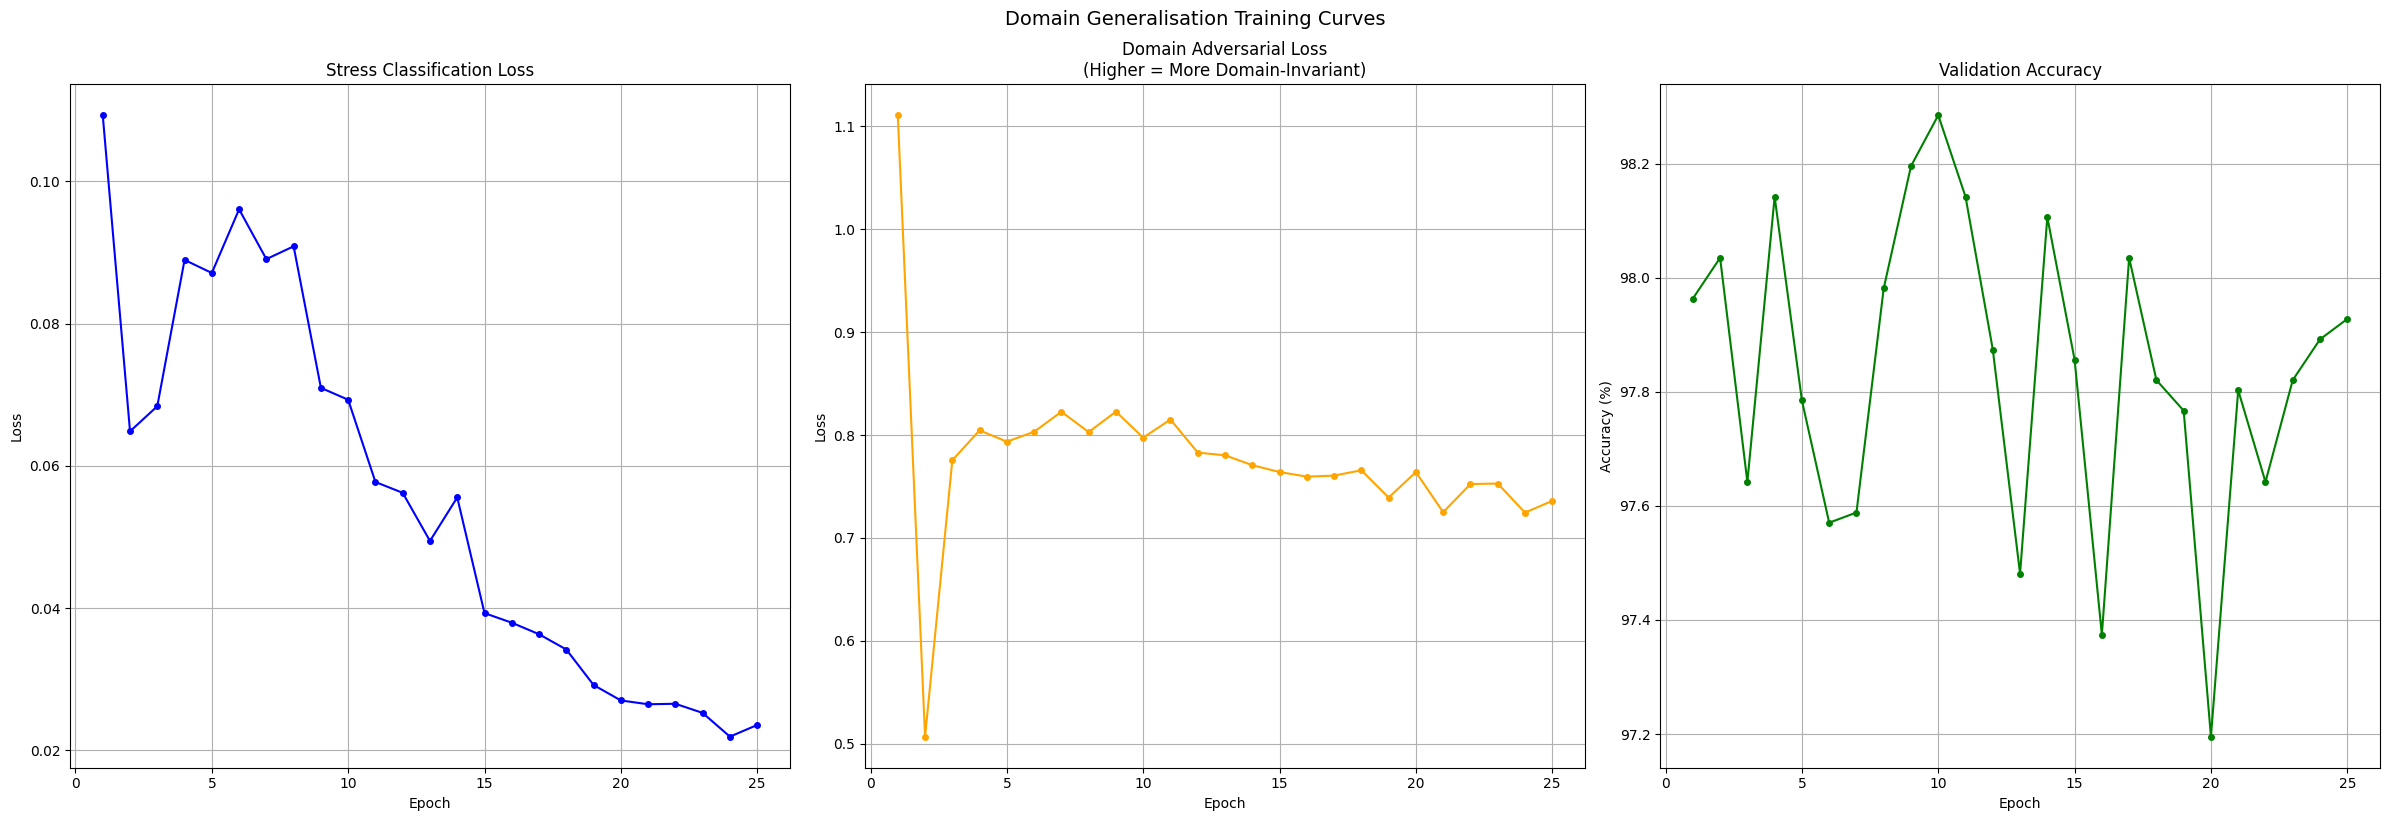

In [ ]:
# SECTION 12 — Training Curves
# =============================================================================
 
def plot_training_curves(stress_losses, domain_losses, val_accs):
    """
    Plots the training history so you can diagnose:
    - Is stress loss decreasing? (model is learning)
    - Is domain loss stable/high? (model is successfully domain-blind)
    - Is val accuracy rising and plateauing? (generalising, not overfitting)
    """
    epochs = range(1, len(stress_losses) + 1)
 
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
 
    # Plot 1: Stress Loss
    axes[0].plot(epochs, stress_losses, 'b-o', markersize=4)
    axes[0].set_title("Stress Classification Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True)
 
    # Plot 2: Domain Loss
    # A healthy domain loss stays relatively HIGH (model can't identify domains)
    # If it drops to near 0, the backbone is still domain-specific → try increasing lambda
    axes[1].plot(epochs, domain_losses, 'r-o', markersize=4, color='orange')
    axes[1].set_title("Domain Adversarial Loss\n(Higher = More Domain-Invariant)")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].grid(True)
 
    # Plot 3: Validation Accuracy
    axes[2].plot(epochs, val_accs, 'g-o', markersize=4)
    axes[2].set_title("Validation Accuracy")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Accuracy (%)")
    axes[2].grid(True)
 
    plt.tight_layout()
    plt.suptitle("Domain Generalisation Training Curves", y=1.02, fontsize=14)
    plt.show()
 
 
plot_training_curves(dg_stress_losses, dg_domain_losses, dg_val_accs)

In [106]:
pred_class, pred_name = predict_stress(dg_model, "/Users/manish/Documents/Semister 2/7. Project/Dataset/Maize Water Stress/WW/WW (18).png")
print(f"Prediction: {pred_name}")

Prediction: Non-stress


In [ ]:
#Section 14 - Save and Load Model

torch.save(dg_model.state_dict(), "dg_model_best.pth")
print("Model saved to dg_model_best.pth")

# To reload later:
# dg_model_loaded = DomainGeneralisationModel(num_domains=3).to(device)
# dg_model_loaded.load_state_dict(torch.load("dg_model_best.pth", map_location=device))
# dg_model_loaded.eval()

Model saved to dg_model_best.pth
